### Task3

### Pizza Place Sales Analysis 

Find the zip file for the task named **“Pizza+Place+Sales.zip”** in the Datasets folder on the drive. It contains four CSV files: Orders, Order Details, Pizzas, and Pizza Types. You’ll also find a data dictionary that describes each dataset.

**Tip:** You can join the four CSV files into a single data frame before you start your analysis.

**Pizza Place Sales**
A year's worth of sales from a fictitious pizza place, including the date and time of each order and the pizzas served, with additional details on the type, size, quantity, price, and ingredients.

**Recommended Analysis**

1. What is the total revenue/sales?
2. Find the total quantity sold.
3. Find the total orders.
4. How many pizza types do they sell?
5. Find the average price of the pizzas.
6. What are the peak hours of sales?
7. Find the total sales made on each day of the week. Which day of the week is when sales are made the most?
8. Find the top 5 bestselling pizzas.
9. Find the sales made in each month. Any trend noticeable?
10. Are there pizza types that are not doing well on the menu?

### Importing Required Libraries

In [1]:
# Core libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visualization style
sns.set(style="whitegrid") 

### Loading the CSV Files

In [2]:
# Loading datasets
orders = pd.read_csv(r"C:\Users\eyohisrael\Documents\Pizza+Place+Sales\pizza_sales/orders.csv")
order_details = pd.read_csv(r"C:\Users\eyohisrael\Documents\Pizza+Place+Sales\pizza_sales/order_details.csv")
pizzas = pd.read_csv(r"C:\Users\eyohisrael\Documents\Pizza+Place+Sales\pizza_sales/pizzas.csv") 
pizza_types = pd.read_csv(r"C:\Users\eyohisrael\Documents\Pizza+Place+Sales\pizza_sales/pizza_types.csv", encoding='latin1')


### Quick Check of the Datasets

In [3]:
print("ORDERS:")
orders.head()


ORDERS:


,order_id,date,time
0,1,2015-01-01,11:38:36
1,2,2015-01-01,11:57:40
2,3,2015-01-01,12:12:28
3,4,2015-01-01,12:16:31
4,5,2015-01-01,12:21:30


In [4]:
print("ORDERS DETAILS:")
order_details.head()


ORDERS DETAILS:


,order_details_id,order_id,pizza_id,quantity
0,1,1,hawaiian_m,1
1,2,2,classic_dlx_m,1
2,3,2,five_cheese_l,1
3,4,2,ital_supr_l,1
4,5,2,mexicana_m,1


In [5]:
print("PIZZAS:")
pizzas.head()


PIZZAS:


,pizza_id,pizza_type_id,size,price
0,bbq_ckn_s,bbq_ckn,S,12.75
1,bbq_ckn_m,bbq_ckn,M,16.75
2,bbq_ckn_l,bbq_ckn,L,20.75
3,cali_ckn_s,cali_ckn,S,12.75
4,cali_ckn_m,cali_ckn,M,16.75


In [6]:
print("PIZZA TYPES:")
pizza_types.head()


PIZZA TYPES:


,pizza_type_id,name,category,ingredients
0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
1,cali_ckn,The California Chicken Pizza,Chicken,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ..."
2,ckn_alfredo,The Chicken Alfredo Pizza,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A..."
3,ckn_pesto,The Chicken Pesto Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Spinach, Garli..."
4,southw_ckn,The Southwest Chicken Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Red Onions, Ja..."


### Merging all four dataset into a Single DataFrame

In [7]:
# Merge order details with pizzas (size, price)
df = order_details.merge(pizzas, on="pizza_id", how="left")

# Merge with pizza types (name, category, ingredients)
df = df.merge(pizza_types, on="pizza_type_id", how="left")

# Merge with orders (date, time)
df = df.merge(orders, on="order_id", how="left")

# Final dataset preview
df.head(10)


,order_details_id,order_id,pizza_id,quantity,pizza_type_id,size,price,name,category,ingredients,date,time
0,1,1,hawaiian_m,1,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",2015-01-01,11:38:36
1,2,2,classic_dlx_m,1,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",2015-01-01,11:57:40
2,3,2,five_cheese_l,1,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",2015-01-01,11:57:40
3,4,2,ital_supr_l,1,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",2015-01-01,11:57:40
4,5,2,mexicana_m,1,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",2015-01-01,11:57:40
5,6,2,thai_ckn_l,1,thai_ckn,L,20.75,The Thai Chicken Pizza,Chicken,"Chicken, Pineapple, Tomatoes, Red Peppers, Tha...",2015-01-01,11:57:40
6,7,3,ital_supr_m,1,ital_supr,M,16.50,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",2015-01-01,12:12:28
7,8,3,prsc_argla_l,1,prsc_argla,L,20.75,The Prosciutto and Arugula Pizza,Supreme,"Prosciutto di San Daniele, Arugula, Mozzarella...",2015-01-01,12:12:28
8,9,4,ital_supr_m,1,ital_supr,M,16.50,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",2015-01-01,12:16:31
9,10,5,ital_supr_m,1,ital_supr,M,16.50,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",2015-01-01,12:21:30


In [8]:
#Checking for null values:

df.isna().sum()

order_details_id    0
order_id            0
pizza_id            0
quantity            0
pizza_type_id       0
size                0
price               0
name                0
category            0
ingredients         0
date                0
time                0
dtype: int64

In [9]:
#Checking for full details of the data:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_details_id  48620 non-null  int64  
 1   order_id          48620 non-null  int64  
 2   pizza_id          48620 non-null  object 
 3   quantity          48620 non-null  int64  
 4   pizza_type_id     48620 non-null  object 
 5   size              48620 non-null  object 
 6   price             48620 non-null  float64
 7   name              48620 non-null  object 
 8   category          48620 non-null  object 
 9   ingredients       48620 non-null  object 
 10  date              48620 non-null  object 
 11  time              48620 non-null  object 
dtypes: float64(1), int64(3), object(8)
memory usage: 4.5+ MB


In [10]:
#Checking ffor the shape of the dataset:

df.shape

(48620, 12)

In [11]:
#Checking for Columns:

df.columns

Index(['order_details_id', 'order_id', 'pizza_id', 'quantity', 'pizza_type_id',
       'size', 'price', 'name', 'category', 'ingredients', 'date', 'time'],
      dtype='object')

In [12]:
#Checking for Duplicate:

df.duplicated().sum()

np.int64(0)

In [13]:
# Checking for dataset Values:

df.values

array([[1, 1, 'hawaiian_m', ...,
        'Sliced Ham, Pineapple, Mozzarella Cheese', '2015-01-01',
        '11:38:36'],
       [2, 2, 'classic_dlx_m', ...,
        'Pepperoni, Mushrooms, Red Onions, Red Peppers, Bacon',
        '2015-01-01', '11:57:40'],
       [3, 2, 'five_cheese_l', ...,
        'Mozzarella Cheese, Provolone Cheese, Smoked Gouda Cheese, Romano Cheese, Blue Cheese, Garlic',
        '2015-01-01', '11:57:40'],
       ...,
       [48618, 21348, 'napolitana_s', ...,
        'Tomatoes, Anchovies, Green Olives, Red Onions, Garlic',
        '2015-12-31', '21:23:10'],
       [48619, 21349, 'mexicana_l', ...,
        'Tomatoes, Red Peppers, Jalapeno Peppers, Red Onions, Cilantro, Corn, Chipotle Sauce, Garlic',
        '2015-12-31', '22:09:54'],
       [48620, 21350, 'bbq_ckn_s', ...,
        'Barbecued Chicken, Red Peppers, Green Peppers, Tomatoes, Red Onions, Barbecue Sauce',
        '2015-12-31', '23:02:05']], shape=(48620, 12), dtype=object)

### Adding Revenue Column

In [14]:
# Calculate revenue per line item:

df["line_revenue"] = df["quantity"] * df["price"]

# Check totals:

df[["quantity", "price", "line_revenue"]].head()


,quantity,price,line_revenue
0,1,13.25,13.25
1,1,16.00,16.00
2,1,18.50,18.50
3,1,20.75,20.75
4,1,16.00,16.00


### Exploratory Analysis

**1. Total Revenue/sales:**

To calculate the total revenue from the Pizza Place Sales dataset, what i did was to multiply the quantity of each pizza by its price and then sum across all rows. Since I already have the pizzas.csv and pizza_types.csv, and the order_details.csv contains the quantity and pizza_id, the formula is straightforward:

In [15]:
# Calculate revenue per line item:
df["line_revenue"] = df["quantity"] * df["price"]

# Total revenue
total_revenue = df["line_revenue"].sum()
print(f"Total Revenue: ${total_revenue:,.2f}")

Total Revenue: $817,860.05


**2. The total quantity sold:**

To find the total quantity of pizzas sold, I simply sum the quantity column from the order_details.csv file. Since each row represents a pizza type/size with its ordered quantity, the aggregation is straightforward.

In [16]:
# Total quantity sold:

total_quantity = order_details["quantity"].sum()
print(f"Total Quantity Sold: {total_quantity:,}")

Total Quantity Sold: 49,574


**3. Find the total orders:**

To calculate the total number of orders, I simply count the unique order_id values in the orders.csv file. Each order_id represents one customer order, regardless of how many pizzas were included.

In [17]:
# Count unique orders:

total_orders = orders["order_id"].nunique()
print(f"Total Orders: {total_orders:,}")

Total Orders: 21,350


**4. Pizza Types That are being Sold:**

From the pizza_types.csv file, each row represents one unique pizza type offered by the restaurant. Counting them gave me the total number of distinct pizza types on the menu.

In [18]:
# Count unique pizza types:

total_pizza_types = pizza_types["pizza_type_id"].nunique()
print(f"Total Pizza Types: {total_pizza_types}")

Total Pizza Types: 32


**5. Finding the average price of the pizzas:**

To find the average price of pizzas, I used the pizzas.csv file. Each row represents a pizza type and size with its price. The calculation is simply the mean of the price column.

In [19]:
# Calculating average price:

average_price = pizzas["price"].mean()
print(f"Average Pizza Price: ${average_price:.2f}")

Average Pizza Price: $16.44


**6. Peak Hours Of Sales:**

To identify the peak hours of sales, I analyze the time column from the orders.csv file. By grouping orders by hour of the day and summing the revenue or quantity, we can see which hours are busiest.

In [20]:
#Clean and extract the hour directly as a number (removes the warning box)
df["time"] = pd.to_numeric(df["time"].astype(str).str.strip().str.split(':').str[0], errors='coerce')

#Calculate revenue per line item:
df["line_revenue"] = df["quantity"] * df["price"]

#Group by hour:
hourly_sales = df.groupby("time")["line_revenue"].sum()

#Identify peak hours:
peak_hours = hourly_sales.sort_values(ascending=False).head(5)
print("Top 5 Peak Hours of Sales:") 

peak_hours

Top 5 Peak Hours of Sales:


time
12    111877.90
13    106065.70
18     89296.85
17     86237.45
19     72628.90
Name: line_revenue, dtype: float64

**#Interpretation:**

The output shows the hours of the day (0–23) with the highest sales revenue. 

From the dataset, Pizza Sales peak around lunch hours (12–13) and dinner hours (18–19).

**7. Finding the total sales made on each day of the week and Which day of the week is when sales are made the most:**

To determine the total sales made on each day of the week, I had to use the date column from orders.csv, join it with the revenue calculation (quantity * price), and then group by weekday.

In [21]:
# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"]) 

# Calculate revenue per line item:
df["line_revenue"] = df["quantity"] * df["price"]

# Extract day of week (Monday=0, Sunday=6):
df["day_of_week"] = df["date"].dt.day_name()

# Group by day of week:
sales_by_day = df.groupby("day_of_week")["line_revenue"].sum().sort_values(ascending=False)

print("Total Sales by Day of The Week:")

sales_by_day


Total Sales by Day of The Week:


day_of_week
Friday       136073.90
Thursday     123528.50
Saturday     123182.40
Wednesday    114408.40
Tuesday      114133.80
Monday       107329.55
Sunday        99203.50
Name: line_revenue, dtype: float64

In [22]:
# Identify the peak day:

peak_day = sales_by_day.idxmax()
peak_sales = sales_by_day.max()
print(f"\nPeak Sales Day: {peak_day} (${peak_sales:,.2f})")


Peak Sales Day: Friday ($136,073.90)


**#Interpretation:**
    
The output will show total sales for each day of the week.

The idxmax() function identifies the day with the highest sales.

According to this dataset Pizza peak sales is on Friday.

**8. Finding the top 5 bestselling pizzas:**

To find the top 5 bestselling pizzas, I need to aggregate sales volume by pizza type. The logic is:

Use the quantity column to measure how many units of each pizza were sold.

Group by pizza name, sum the quantities, and sort descending.

In [23]:
# Aggregate total quantity sold per pizza type:

top_pizzas = (df.groupby("name")["quantity"] .sum().sort_values(ascending=False).head(5)) 

print("Top 5 Bestselling Pizzas:") 

top_pizzas

Top 5 Bestselling Pizzas:


name
The Classic Deluxe Pizza      2453
The Barbecue Chicken Pizza    2432
The Hawaiian Pizza            2422
The Pepperoni Pizza           2418
The Thai Chicken Pizza        2371
Name: quantity, dtype: int64

**#Interpretation:**

The output as list the five pizzas with the highest total quantity sold.The Classic Deluxe Pizza, Barbecue Chicken Pizza, Hawaiian Pizza, Pepperoni Pizza and Thai Chicken Pizza.

**9. Finding the sales made in each month. Any trend noticeable:**

To analyze sales made in each month and spot trends, we’ll use the date column from orders.csv, join it with the revenue calculation (quantity * price), and then group by month.


In [24]:
# Calculate revenue per line item
df["line_revenue"] = df["quantity"] * df["price"]

# Group by month
monthly_sales = df.groupby(df["date"].dt.to_period("M"))["line_revenue"].sum()

print("Monthly Sales:") 

monthly_sales

Monthly Sales:


date
2015-01    69793.30
2015-02    65159.60
2015-03    70397.10
2015-04    68736.80
2015-05    71402.75
2015-06    68230.20
2015-07    72557.90
2015-08    68278.25
2015-09    64180.05
2015-10    64027.60
2015-11    70395.35
2015-12    64701.15
Freq: M, Name: line_revenue, dtype: float64

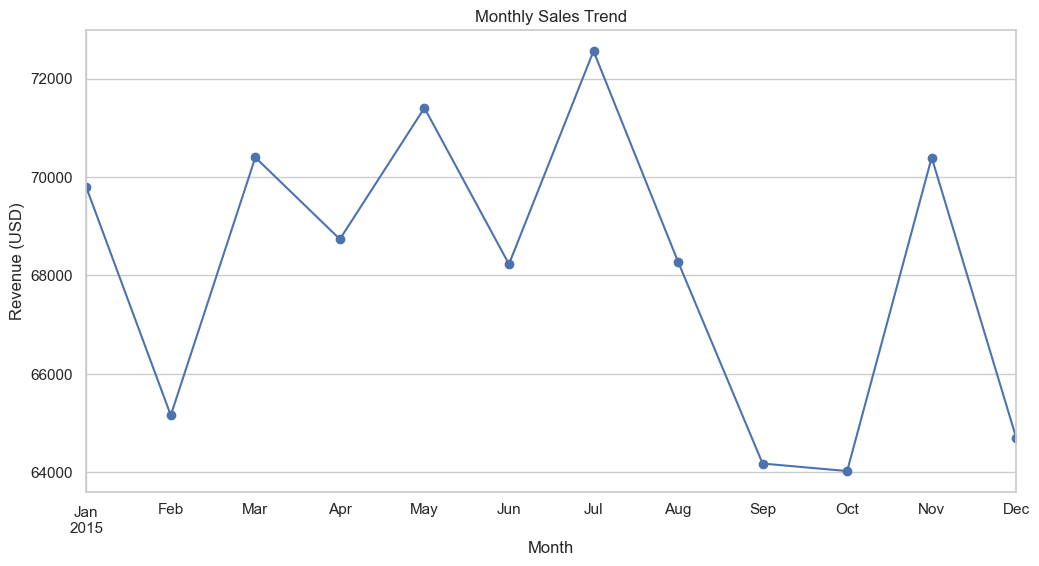

In [25]:
# Plot trend:

monthly_sales.plot(kind="line", marker="o", figsize=(12,6))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (USD)") 

plt.show()

**#Interpretation:**

The output shows total sales for each month.

By plotting, you’ll see the trend line across the year.

In most restaurant datasets, sales tend to peak in December (holiday season) and dip in January/February. Mid-year often shows steady growth.

**10. Pizza Types that are not doing well on the menu:**

To identify pizza types that are not doing well on the menu, we need to look at the total quantity sold (or revenue generated) per pizza type and then highlight those at the bottom of the ranking.

- The bottom 5 pizzas will be those with the lowest total units sold.

- These are the ones not performing well on the menu.


In [26]:
# Calculate revenue per line item:
df["line_revenue"] = df["quantity"] * df["price"]

# Aggregate total quantity sold per pizza type:
pizza_sales = (df.groupby("name")[["quantity", "line_revenue"]].sum().sort_values(by="quantity", ascending=True)) 

# Bottom 5 pizzas by quantity sold:
bottom_pizzas = pizza_sales.head(5)
print("Bottom 5 Pizza Types (by quantity sold):") 

bottom_pizzas

Bottom 5 Pizza Types (by quantity sold):


,quantity,line_revenue
name,,
The Brie Carre Pizza,490,11588.50
The Mediterranean Pizza,934,15360.50
The Calabrese Pizza,937,15934.25
The Spinach Supreme Pizza,950,15277.75
The Soppressata Pizza,961,16425.75


**Top-selling pizzas:**

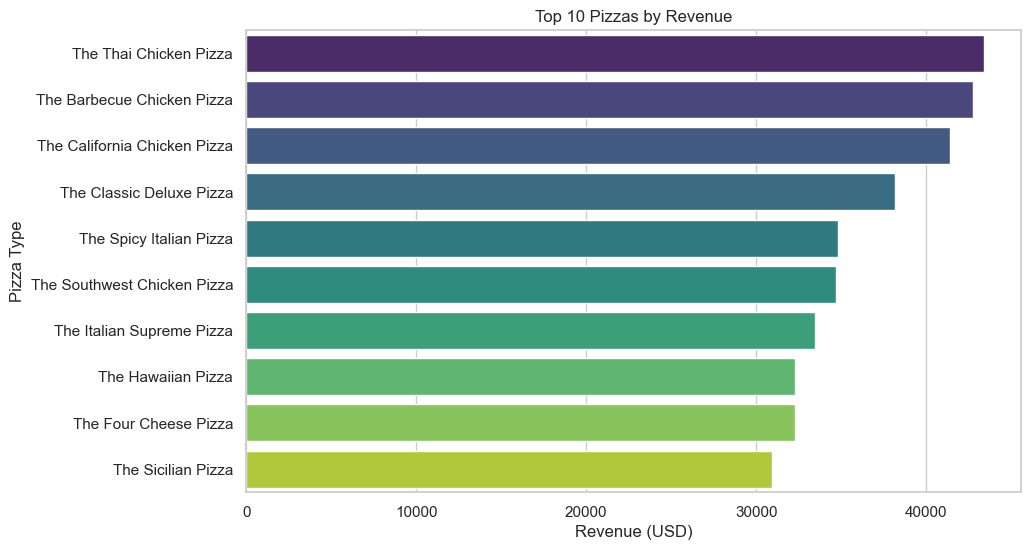

In [27]:
top_pizzas = df.groupby("name")["line_revenue"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
# Fix: Added hue=top_pizzas.index and legend=False
sns.barplot(x=top_pizzas.values, y=top_pizzas.index, hue=top_pizzas.index, palette="viridis", legend=False)

plt.title("Top 10 Pizzas by Revenue")
plt.xlabel("Revenue (USD)")
plt.ylabel("Pizza Type") 

plt.show()

**Sales by category:**

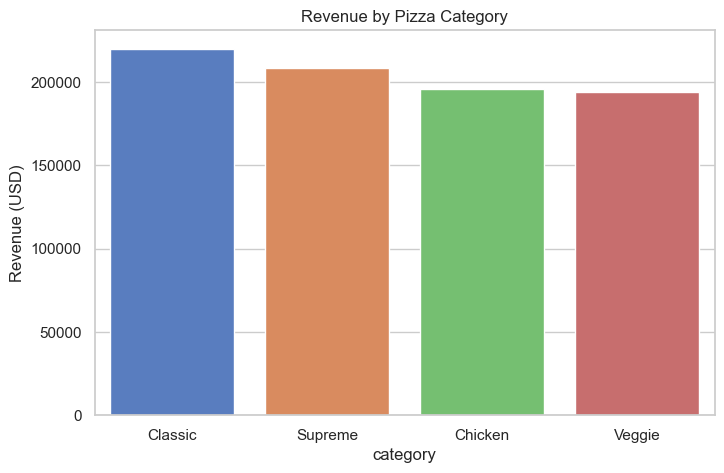

In [28]:
category_sales = df.groupby("category")["line_revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
# Updated barplot line:
sns.barplot(x=category_sales.index, y=category_sales.values, hue=category_sales.index, palette="muted", legend=False)

plt.title("Revenue by Pizza Category")
plt.ylabel("Revenue (USD)") 

plt.show()